In [62]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from bct.algorithms.clustering import clustering_coef_wu
from bct.utils.other import threshold_proportional
from itertools import combinations
from scipy.sparse.csgraph import shortest_path, laplacian
from scipy.linalg import eigh
from scipy.io import mmread
from scipy.spatial.distance import cdist
from small_world_propensity import SWP

### Lattice formula idea:

Based on Figure 3, they're using a ring lattice, where the inner "core" has the smallest distances and therefore the highest edge weights.

Need to calculate the radius, r, of the lattice. Not clear how exactly to do this, but it's basically average degree or density, and supplementals say they're preserving the number of edges. So something like this:

    N = adj.shape[0]
    upper = np.triu(adj, k=1)
    E = np.count_nonzero(upper)
    r = int(np.round(E/N))

In [2]:
# Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')

In [59]:
def make_lattice_null(adj):
    """
    Latticizes an inputted network. This is taken from Results: Generating Weighted 
    Small-World Networks, and Figure 3. In the Supplementals, they say that they use 
    Euclidean distance, but that requires some knowledge of where the nodes are in space. 
    I have some idea of how to get the Euclidean distances by using 
    nilearn.plotting.find_parcellation_cut_coords, but that requires having a .nii file, and,
    most importantly, they don't describe using Euclidean distance in the main text.

    This instead creates a circulant graph using the radius of the observed network. It maintains
    the number of edges and the edge weight distribution, distributing higher weights to edges
    with shorter distances around the ring.
    
    """
    Makes lattice null graph with the same number of edges and weight distribution as the input graph. 
    The highest weights are distributed to the nodes with shortest distance.

    Inputs
    ---
    adj  :  Weighted, undirected adjacency matrix.
           

    Returns
    ---
    lattice_null : Lattice null graph adjacency matrix. 

    
    """

    adj = adj.astype(float)
    adj = (adj + adj.T) / 2
    # Use only largest connected component (maybe not correct, but ideally all graphs will be connected)
    G = nx.Graph(adj)
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G0 = G.subgraph(largest_cc)
        adj = nx.adjacency_matrix(G0).toarray()
    N = adj.shape[0]

    # Calculate the observed radius
    upper = np.triu(adj, k=1)
    E = np.count_nonzero(upper)
    r = int(np.round(E/N))
    
    # Extract upper triangle edges and their weights
    rows, cols = np.triu_indices(N, k=1)
    weights = adj[rows, cols]
    # Sort in descending order
    weights_sorted = np.sort(weights)[::-1]
    
    node_order = np.arange(N)
    # Create circular lattice using radius,r, and N
    lattice_graph = nx.circulant_graph(n=N, offsets=range(1, r+1))
    # Get edges and compute distances
    lattice_edges = list(lattice_graph.edges())
    # Calculate circular distances for assigning weights
    lattice_distances = []
    for i, j in lattice_edges:
        # Minimum distance around the ring
        dist = min(abs(i - j), N - abs(i - j))
        lattice_distances.append(dist)

    # Sort distances; shorter distances get higher weights
    sorted_indices = np.argsort(lattice_distances)
    sorted_edges = [lattice_edges[idx] for idx in sorted_indices]

    # Assign weights
    lattice_adj = np.zeros((N, N))
    num_lattice_edges = len(sorted_edges)
    num_obs_edges = len(weights)

    # Check and handle edge count mismatches
    if num_lattice_edges != num_obs_edges:
        # Trim or pad
        num_assign = min(num_lattice_edges, num_obs_edges)
        assigned_weights = weights_sorted[:num_assign]
    else:
        num_assign = num_lattice_edges
        assigned_weights = weights_sorted

    for idx, (i, j) in enumerate(sorted_edges[:num_assign]):
        lattice_adj[i, j] = assigned_weights[idx]
        lattice_adj[j, i] = assigned_weights[idx]

    inverse_order = np.argsort(node_order)
    lattice_adj = lattice_adj[inverse_order][:, inverse_order]

    return lattice_adj



In [60]:
foo = make_lattice_null(sc)

<Axes: >

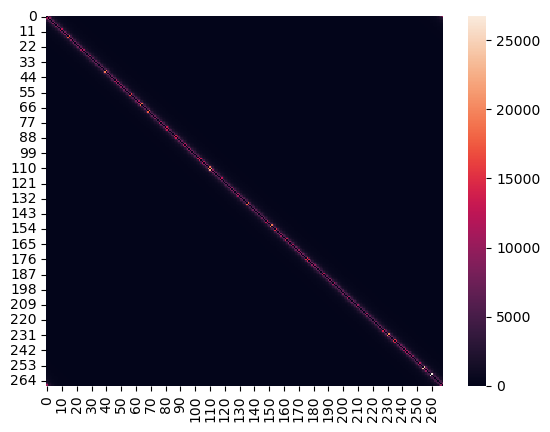

In [61]:
sns.heatmap(foo)

In [43]:
adj = sc.copy()
N = adj.shape[0]
# Calculate the appropriate radius
upper = np.triu(adj, k=1)
E = np.count_nonzero(upper)
r = int(np.round(E/N))
grid = nx.circulant_graph(n=N, offsets=range(1, r+1))

In [45]:
nx.write_graphml(grid, 'grid.graphml')

In [48]:
r*2

194

In [49]:
N = adj.shape[0]
upper = np.triu(adj, k=1)
E_obs = np.count_nonzero(upper)
expected_edges = N * 97

print(f"N = {N}")
print(f"Observed edges: {E_obs}")
print(f"Expected edges (N * r): {expected_edges}")
print(f"Difference: {E_obs - expected_edges}")
print(f"Relative error: {(E_obs - expected_edges)/E_obs:.2%}")

N = 268
Observed edges: 25915
Expected edges (N * r): 25996
Difference: -81
Relative error: -0.31%


In [50]:
N/2

134.0

In [51]:
avg_degree_obs = 2 * E_obs / N
avg_degree_lattice = 2 * r

print(f"Observed average degree: {avg_degree_obs:.2f}")
print(f"Lattice average degree: {avg_degree_lattice:.2f}")

Observed average degree: 193.40
Lattice average degree: 194.00


In [52]:
np.mean(list(dict(nx.Graph(sc).degree())))

np.float64(133.5)

In [63]:
spis = ['additive_noise', 'barycenter', 'coherence_mag', 'cointegration', 'covariance',
        'directed_info', 'granger', 'integrated_info', 'itakura', 'phase_lag',
        'phase_slope_spectral', 'phase_slope_wavelet', 'power_env_corr', 'transfer_entropy']

spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
subs = os.listdir(spi_dir)

In [64]:
results_sc = {'SWP': [],
              'delta_C': [],
              'delta_L': []
             }
disconnected = []
for i, sub in tqdm(enumerate(subs)):
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')
    try:
        sc = np.load(sc_path)
        G = nx.Graph(sc)
        if not nx.is_connected(G):
            disconnected.append(sub)
    except:
        pass
    swp, delta_C, delta_L = SWP(sc)
    results_sc['SWP'].append(swp)
    results_sc['delta_C'].append(delta_C)
    results_sc['delta_L'].append(delta_L)
df = pd.DataFrame(results_sc, columns = results_sc.keys())
df.to_csv('sc_results.csv')

213it [02:51,  1.27it/s]

Graph is not fully connected.


338it [04:37,  1.22it/s]


In [66]:
swp, delta_C, delta_L = SWP(elegans_adj)

Graph is not fully connected.


In [67]:
swp

np.float64(0.6586812554438475)

In [ ]:
results_fc = {spi: {'SWP': [], 'delta_C': [], 'delta_L': []} for spi in spis}
results_sc = []
for spi in spis:
    for sub in subs:
        fc_path = os.path.join(spi_dir, sub, f'{spi}_symmetrize.npy')
        fc = np.load(fc_path)
        # Turn into graph, do maximum spanning tree
        G = nx.Graph(fc)
        G0 = nx.maximum_spanning_tree(G)
        adj = nx.adjacency_matrix(G0).toarray()
        
        swp, delta_C, delta_L = SWP(adj)
        results_fc[spi]['SWP'].append(swp)
        results_fc[spi]['delta_C'].append(delta_C)
        results_fc[spi]['delta_L'].append(delta_L)